## Handling Missing Values in the Dataset

In [1]:
import os
from collections import Counter
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
dir = "dataset"

dataset = os.listdir(dir)
len(dataset)

9927

In [3]:
count_above_90 = 0
for img_name in dataset:
    parts = img_name.split('_')
    age = int(parts[0])
    if age == 85:
        count_above_90 += 1
print(f"Number of images with age above 90: {count_above_90}")

Number of images with age above 90: 132


#### Plotting graph as all image above 90 as one class

In [12]:
age_gender_counter = Counter()

for img_name in dataset:
    parts = img_name.split('_')
    age = int(parts[0])
    gender = int(parts[1])

    gender_str = 'male' if gender == 0 else "female"

    age_gender_counter[(age, gender_str)] += 1

len(age_gender_counter)

188

In [13]:
new_counter = Counter()
for (age, gender), cnt in age_gender_counter.items():
    if isinstance(age, int) and age > 90:
        new_counter[('90+', gender)] += cnt
    else:
        new_counter[(age, gender)] += cnt

len(new_counter)

182

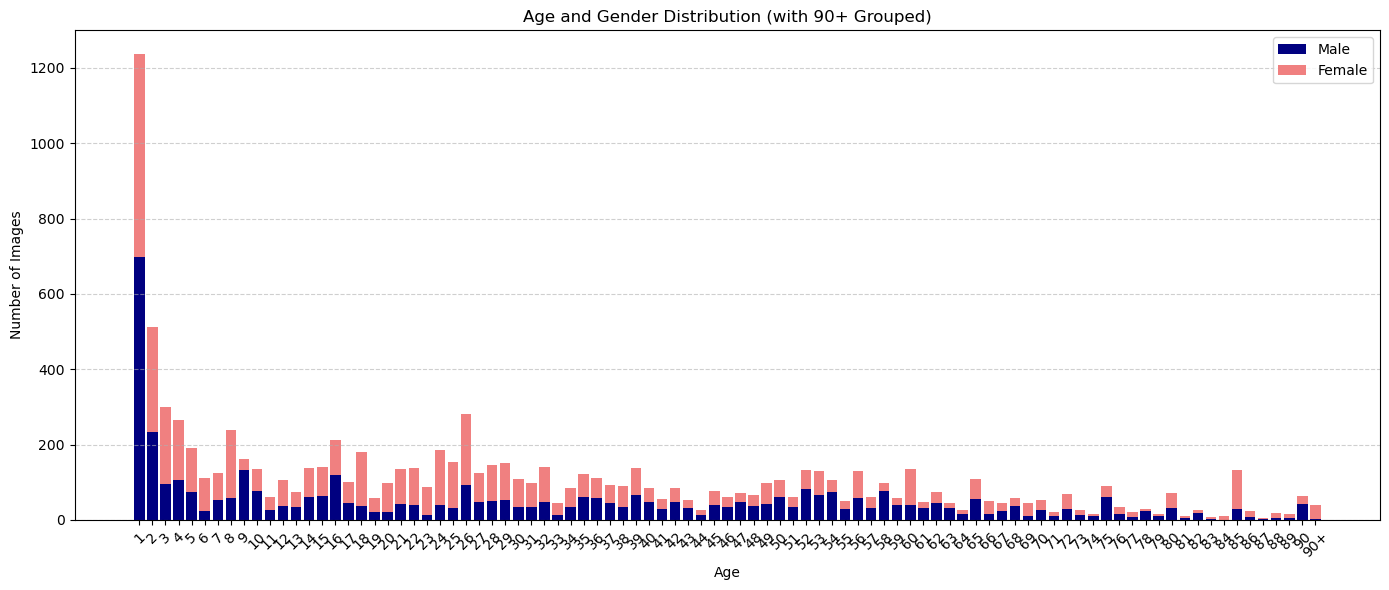

In [14]:
numeric_ages = sorted({a for a, _ in new_counter.keys() if isinstance(a, int)})
age_labels = [str(a) for a in numeric_ages]
if any(a == '90+' for a, _ in new_counter.keys()):
    age_labels.append('90+')

# numeric x positions
x = np.arange(len(age_labels))

# build counts in the same order
male_counts = []
female_counts = []
for label in age_labels:
    key = int(label) if label != '90+' else '90+'
    male_counts.append(new_counter.get((key, 'male'), 0))
    female_counts.append(new_counter.get((key, 'female'), 0))

male_counts = np.array(male_counts, dtype=int)
female_counts = np.array(female_counts, dtype=int)

# --- plot (fresh figure) ---
plt.figure(figsize=(14, 6))
plt.bar(x, male_counts, label='Male', color='navy')
plt.bar(x, female_counts, bottom=male_counts, label='Female', color='lightcoral')

plt.xlabel('Age')
plt.ylabel('Number of Images')
plt.title('Age and Gender Distribution (with 90+ Grouped)')
plt.xticks(x, age_labels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

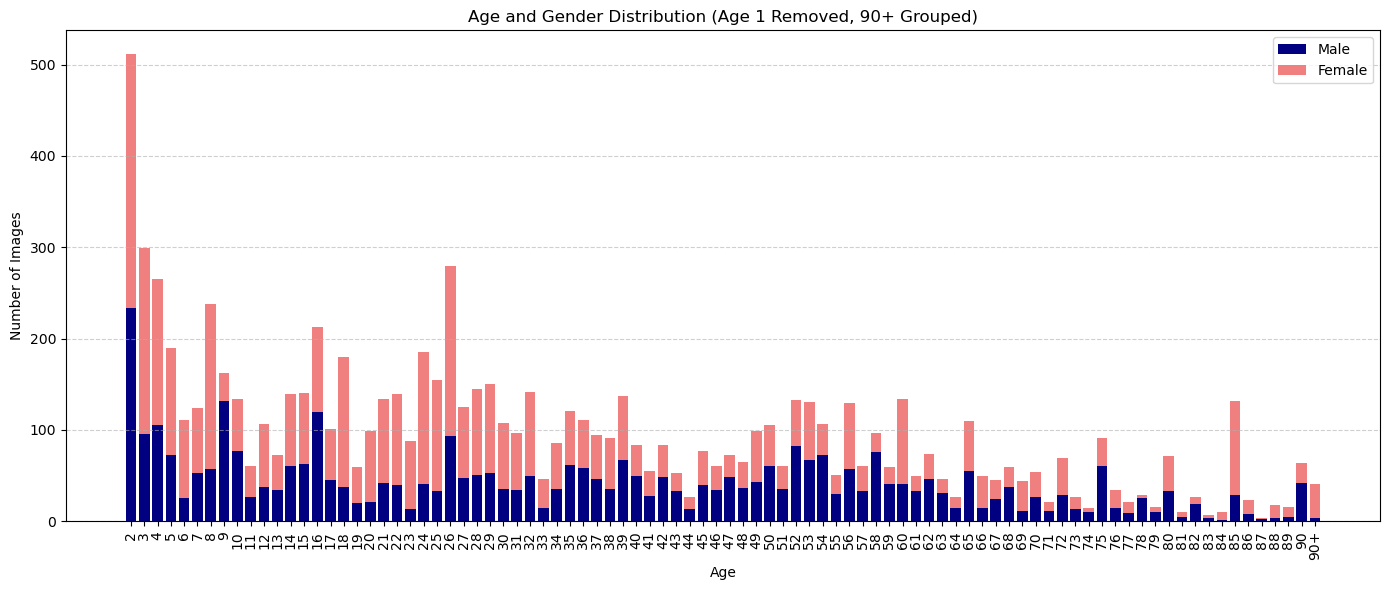

In [15]:
# Not plotting age 1 for clear view of other ages
filtered_counter = {k: v for k, v in new_counter.items() if k[0] != 1}

numeric_ages = sorted({a for a, _ in filtered_counter.keys() if isinstance(a, int)})
age_labels = [str(a) for a in numeric_ages]
if any(a == '90+' for a, _ in filtered_counter.keys()):
    age_labels.append('90+')

# --- Step 3: Build count arrays ---
x = np.arange(len(age_labels))
male_counts = [filtered_counter.get((int(label) if label != '90+' else '90+', 'male'), 0) for label in age_labels]
female_counts = [filtered_counter.get((int(label) if label != '90+' else '90+', 'female'), 0) for label in age_labels]

# --- Step 4: Plot ---
plt.figure(figsize=(14, 6))
plt.bar(x, male_counts, label='Male', color='navy')
plt.bar(x, female_counts, bottom=male_counts, label='Female', color='lightcoral')

plt.xlabel('Age')
plt.ylabel('Number of Images')
plt.title('Age and Gender Distribution (Age 1 Removed, 90+ Grouped)')
plt.xticks(x, age_labels, rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### All images in dataset of age > 90 classifying as 91 

In [4]:
count_age_converted = 0

for img_name in dataset:
    parts = img_name.split('_')
    old_path = os.path.join(dir, img_name)

    try:
        age = int(parts[0])
    except ValueError: 
        print(f"Skipping file (bad name): {img_name}")
        continue

    if age > 90:
        age = 91
        count_age_converted += 1

        new_name = f"{age}_{parts[1]}_{parts[2]}_{parts[3]}"
        new_path = os.path.join(dir, new_name)

        os.rename(old_path, new_path)
        print(f"Renamed: {img_name} → {new_name}")

print(f"\n Total images renamed (age > 90 → 91): {count_age_converted}")


Renamed: 93_1_0_20170110141221528.jpg → 91_1_0_20170110141221528.jpg
Renamed: 96_1_2_20170105174624519.jpg → 91_1_2_20170105174624519.jpg
Renamed: 96_1_0_20170110173805290.jpg → 91_1_0_20170110173805290.jpg
Renamed: 92_1_2_20170110182855209.jpg → 91_1_2_20170110182855209.jpg
Renamed: 92_0_0_20170111223719595.jpg → 91_0_0_20170111223719595.jpg
Renamed: 95_1_0_20170110161313778.jpg → 91_1_0_20170110161313778.jpg
Renamed: 96_1_2_20170110183528193.jpg → 91_1_2_20170110183528193.jpg
Renamed: 96_1_2_20170110183043609.jpg → 91_1_2_20170110183043609.jpg
Renamed: 100_1_2_20170110182836729.jpg → 91_1_2_20170110182836729.jpg
Renamed: 92_1_0_20170110133307879.jpg → 91_1_0_20170110133307879.jpg
Renamed: 93_1_2_20170110173119858.jpg → 91_1_2_20170110173119858.jpg
Renamed: 92_1_0_20170110182402526.jpg → 91_1_0_20170110182402526.jpg
Renamed: 92_1_0_20170110182333823.jpg → 91_1_0_20170110182333823.jpg
Renamed: 96_1_2_20170110175716420.jpg → 91_1_2_20170110175716420.jpg
Renamed: 96_1_0_20170110182515404